## 04.P Geospatial Data Problem Set – Summarizing Airborne Snow Observatory Data

__Background:__ For your graduate research, you are using lidar-derived snow water equivalent (SWE) estimates to assimilate into a physics based hydrology model to make streamflow predictions. In thinking through your hypotheses portions of the landscape where SWE data will have the most impact, you are reminded of a figure you saw in a presentation at a recent meeting. The figure shows how the distribution of SWE and land area across a range of elevation interact to control the distribution of water storage in the landscape. The figure looked like the following:

<img src='aso_swe.png' alt='Upper Colorado ASO Analysis' width='750' style='display: block; margin: 0 auto'/>

You already have grids of estimated SWE from the Airborne Snow Observatory (ASO) for 4 separate dates at a 50 m spatial resolution, and a coregistered digital elevation model of the study area – the East River in the Colorado Rocky Mountains.  

__Task:__ Use the skills you've developed and the example notebooks you've examined in this module to create an image like the above. The ASO and coregistered DEM can be found in [this Google Drive folder](https://drive.google.com/drive/u/0/folders/1SkjOWPPJe5N25arCW6qbf2ZJWQsrUAAp). Use any of the four ASO files, which corresponds to 2 different dates in 2018 or 2019, or write your code generically to plot any or all dates. You should only need `rasterio`, `numpy`, and `matplotlib` to create this figure.    

In [1]:
import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
from scipy.ndimage import label
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [ ]:
dem_name = "data/coge_dem_50m.tif"
dem_data =  rio.open(dem_name)
dem_array=dem_data.read(1)

plot_label1="USCOGE_20180331"
plot_label2="USCOGE_20180524"
plot_label3="USCOGE_20190407"
plot_label4="USCOGE_20190610"

swe_name1="data/ASO_50M_SWE_USCOGE_20180331.tif"
swe_name2="data/ASO_50M_SWE_USCOGE_20180524.tif"
swe_name3="data/ASO_50M_SWE_USCOGE_20190407.tif"
swe_name4="data/ASO_50M_SWE_USCOGE_20190610.tif"

swe_data1 = rio.open(swe_name1)
swe_array1=swe_data1.read(1)

swe_array2=rio.open(swe_name2).read(1)
swe_array3=rio.open(swe_name3).read(1)
swe_array4=rio.open(swe_name4).read(1)

1) 处理Elevation dem bins(分箱)

In [5]:
def elevation_dem(dem_array):
    # Compute basic descriptive stats to summarize the elevation distribution
    zmin = np.nanmin(dem_array)
    zmax = np.nanmax(dem_array)
    zmean = np.nanmean(dem_array)

    zstats = f'''
    Elevation Statistics:
    Number of columns [east-west]: {dem_array.shape[1]} 
    Number of rows [north-south]: {dem_array.shape[0]}
    Minimum elevation: {zmin:.{2}f} m
    Maximum elevation: {zmax:.{2}f} m
    Mean elevation: {zmean:.{2}f} m
    '''
    #print(zstats)

    delta_z = 100.0
    # define elevation bins
    z_bot = np.floor(zmin/delta_z)*delta_z
    z_top = np.ceil(zmax/delta_z)*delta_z
    # generate bin edges 
    z_intervals = np.arange(z_bot, z_top+delta_z, delta_z)
    z_centers = (z_intervals[:-1] + z_intervals[1:]) / 2
    nz = z_intervals.size
    bin_index = np.digitize(dem_array, z_intervals)
    
    zhist = np.array([np.sum(bin_index == i) for i in range(1, nz+1)])
    zfrac = zhist / zhist.sum()

    return z_centers, zfrac, nz, bin_index

In [6]:
z_centers, zfrac, nz, bin_index = elevation_dem(dem_array)

In [7]:
dx = 50
dy = 50 
cell_area = dx * dy

area_m2 = []

for i in range(1, nz):
    count = np.sum(bin_index == i)
    area_m2.append(count * cell_area)

area_m2 = np.array(area_m2)
area_km2 = area_m2 / 1e6

In [8]:
area_m2.shape

(23,)

2）处理swe 数据

In [9]:
# 1) 打印基本信息
print("---- Basic Info ----")
print("Width (columns):", swe_data1.width)
print("Height (rows):", swe_data1.height)
print("Number of bands:", swe_data1.count)
print("Data type:", swe_data1.dtypes)

# 2) 打印坐标系
print("\n---- CRS ----")
print(swe_data1.crs)

# 3) 仿射变换（像元大小、左上角坐标）
print("\n---- Transform ----")
print(swe_data1.transform)

# 4) 数据边界
print("\n---- Bounds ----")
print(swe_data1.bounds)

# 5) 打印某个 band 的 numpy array 结构
band1 = swe_data1.read(1)
print("\n---- Band 1 Array Info ----")
print("Array shape:", band1.shape)
print("Array dtype:", band1.dtype)
print("Min / Max:", band1.min(), "/", band1.max())

# 若想看前10个值
print("\nFirst 10 values in first row:")
print(band1[0, :10])

print("Nodata value:", swe_data1.nodata)

---- Basic Info ----
Width (columns): 924
Height (rows): 1033
Number of bands: 1
Data type: ('float32',)

---- CRS ----
EPSG:32613

---- Transform ----
| 50.00, 0.00, 305139.00|
| 0.00,-50.00, 4330251.00|
| 0.00, 0.00, 1.00|

---- Bounds ----
BoundingBox(left=305139.0, bottom=4278600.895575063, right=351339.093406236, top=4330251.0)

---- Band 1 Array Info ----
Array shape: (1033, 924)
Array dtype: float32
Min / Max: -9999.0 / 3.1331856

First 10 values in first row:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Nodata value: -9999.0


In [21]:
def swe_clean_function(swe_array):
    # Step 1: Replace nodata (-9999) with NaN
    swe_clean = swe_array.copy()
    swe_clean[swe_clean == -9999.0] = np.nan

    # Step 2: Identify all SWE == 0 pixels
    zero_mask = (swe_clean == 0)

    # Step 3: Use connected-component labeling
    labeled, num_features = label(zero_mask)

    # Step 4: Find the largest connected 0 region (the invalid block)
    sizes = [(labeled == i).sum() for i in range(1, num_features+1)]

    if len(sizes) > 0:
        largest_region = np.argmax(sizes) + 1

    # Step 5: Mask it
    swe_clean[labeled == largest_region] = np.nan
    return swe_clean

In [11]:
def swe_tif(swe_array, bin_index, nz):
    # Step 1: Replace nodata (-9999) with NaN
    swe_clean = swe_array.astype("float32").copy()
    swe_clean[swe_clean == -9999.0] = np.nan

    # Step 2: Identify SWE==0 connected regions
    zero_mask = (swe_clean == 0)
    labeled, num_features = label(zero_mask)

    # Step 3: Find largest connected region (invalid block)
    if num_features > 0:
        sizes = [(labeled == i).sum() for i in range(1, num_features + 1)]
        largest_region = np.argmax(sizes) + 1
        # Step 4: Mask the invalid block
        swe_clean[labeled == largest_region] = np.nan

    mean_swe = []
    median_swe = []
    std_swe = []

    for i in range(1, nz):
        vals = swe_clean[bin_index == i]
        vals = vals[~np.isnan(vals)]

        if len(vals) > 0:
            mean_swe.append(np.nanmean(vals))
            median_swe.append(np.nanmedian(vals))
            std_swe.append(np.nanstd(vals))
        else:
            mean_swe.append(np.nan)
            median_swe.append(np.nan)
            std_swe.append(np.nan)

    return swe_clean, np.array(mean_swe), np.array(median_swe), np.array(std_swe)

In [22]:
swe_unclean1,mean_sweun1, median_sweun1, std_sweun1 = swe_tif(swe_array1,bin_index,nz)
swe_clean1,mean_swe1, median_swe1, std_swe1 = swe_tif(swe_clean_function(swe_array1),bin_index,nz)
swe_clean2,mean_swe2, median_swe2, std_swe2 = swe_tif(swe_clean_function(swe_array2),bin_index,nz)
swe_clean3,mean_swe3, median_swe3, std_swe3 = swe_tif(swe_clean_function(swe_array3),bin_index,nz)
swe_clean4,mean_swe4, median_swe4, std_swe4 = swe_tif(swe_clean_function(swe_array4),bin_index,nz)

In [13]:
def swe_volumn(mean_swe, area_km2):
    swe_volumn = mean_swe * area_km2
    return swe_volumn

In [36]:
swe_volumnun1=swe_volumn(mean_sweun1,area_km2)
swe_volumn1=swe_volumn(mean_swe1,area_km2)
swe_volumn2=swe_volumn(mean_swe2,area_km2)
swe_volumn3=swe_volumn(mean_swe3,area_km2)
swe_volumn4=swe_volumn(mean_swe4,area_km2)

In [15]:
def plot_triple(z_centers, mean_swe, std_swe, median_swe,area_km2,swe_volumn,plot_label):
    delta_z =100
    fig, axs = plt.subplots(
        nrows=1,ncols=3, figsize=(16, 10)
    )

    # 图 1：SWE Mean / Median / ±1 Std（带状图）
    axs[0].fill_betweenx( y=z_centers,
        x1=(mean_swe - std_swe)*1000,
        x2=(mean_swe + std_swe)*1000,
        color='lightblue', alpha=0.4,
        label="Mean ± 1 Std Dev"
    )

    axs[0].plot(
        mean_swe*1000,
        z_centers, 
        color='blue',linewidth=2, label='Mean SWE'
    )

    axs[0].plot(
        median_swe*1000,
        z_centers,
        color='black', linestyle='--', linewidth=2, label='Median SWE'
    )

    axs[0].set_xlabel("SWE (mm)")
    axs[0].set_ylabel("Elevation (m)")
    axs[0].grid(axis='x', linestyle='--', alpha=0.4)
    axs[0].legend(fontsize=9)

    # 图 2：SWE volumn vs elevation（你的 swe_volumn）
    axs[1].barh(
        y=z_centers,
        width=area_km2, height=delta_z * 0.8, color='lightgreen', edgecolor='k'
    )

    axs[1].set_xlabel("Area (km²)")
    axs[1].grid(axis='x', linestyle='--', alpha=0.4)

    # 图 3：Area vs elevation（面积）

    axs[2].barh(
        y=z_centers,
        width=swe_volumn, height=delta_z * 0.8, color='skyblue', edgecolor='k'
    )

    axs[2].set_xlabel("SWE Volume (Mm³)")
    axs[2].grid(axis='x', linestyle='--', alpha=0.4)

    # 全局布局
    for ax in axs:
        ax.tick_params(axis='both', labelsize=11)

    fig.suptitle(plot_label, fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

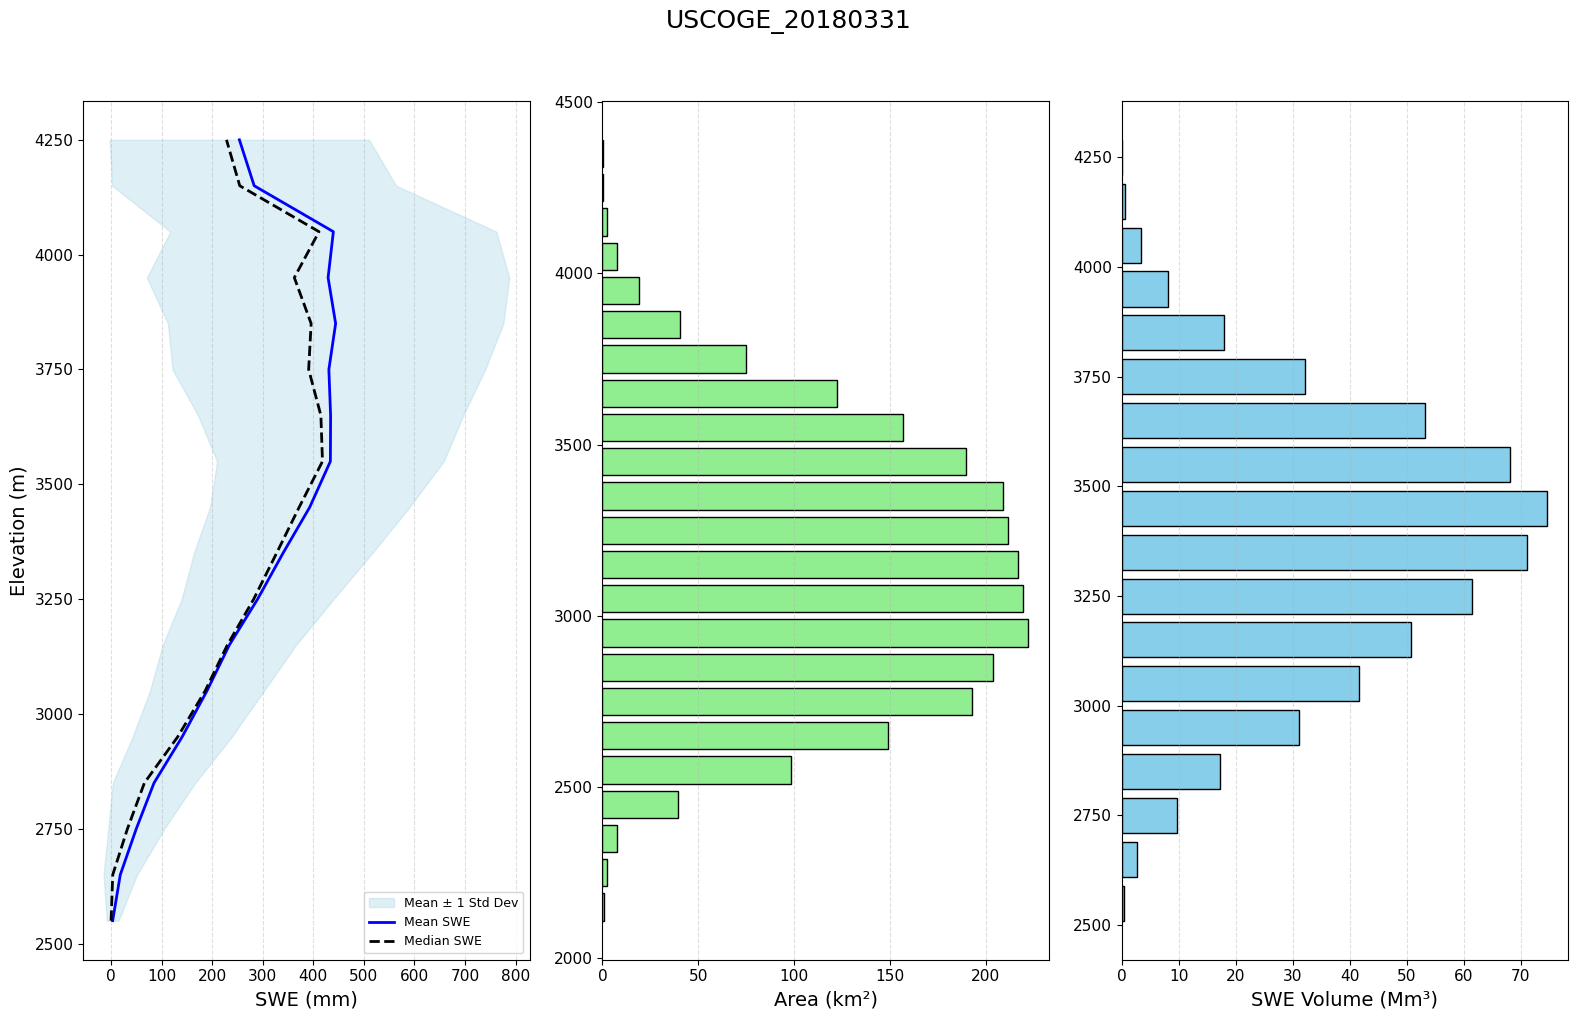

In [24]:
plot_triple(z_centers, mean_swe1, std_swe1, median_swe1,area_km2,swe_volumn1,plot_label1)

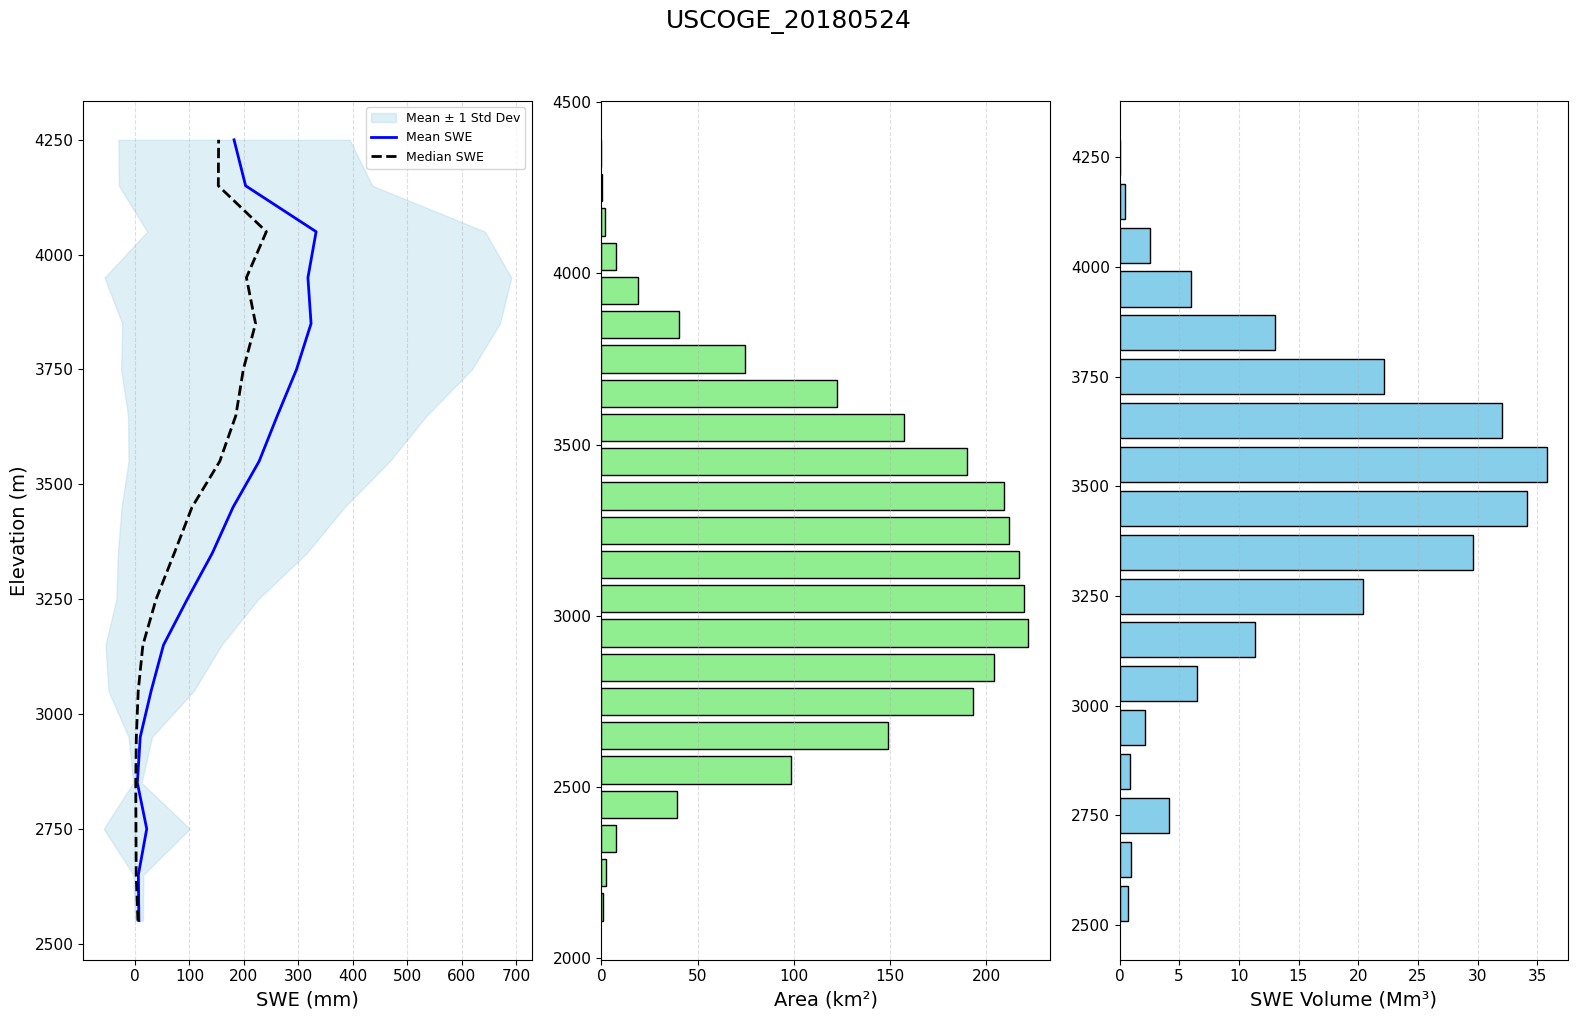

In [25]:
plot_triple(z_centers, mean_swe2, std_swe2, median_swe2,area_km2,swe_volumn2,plot_label2)

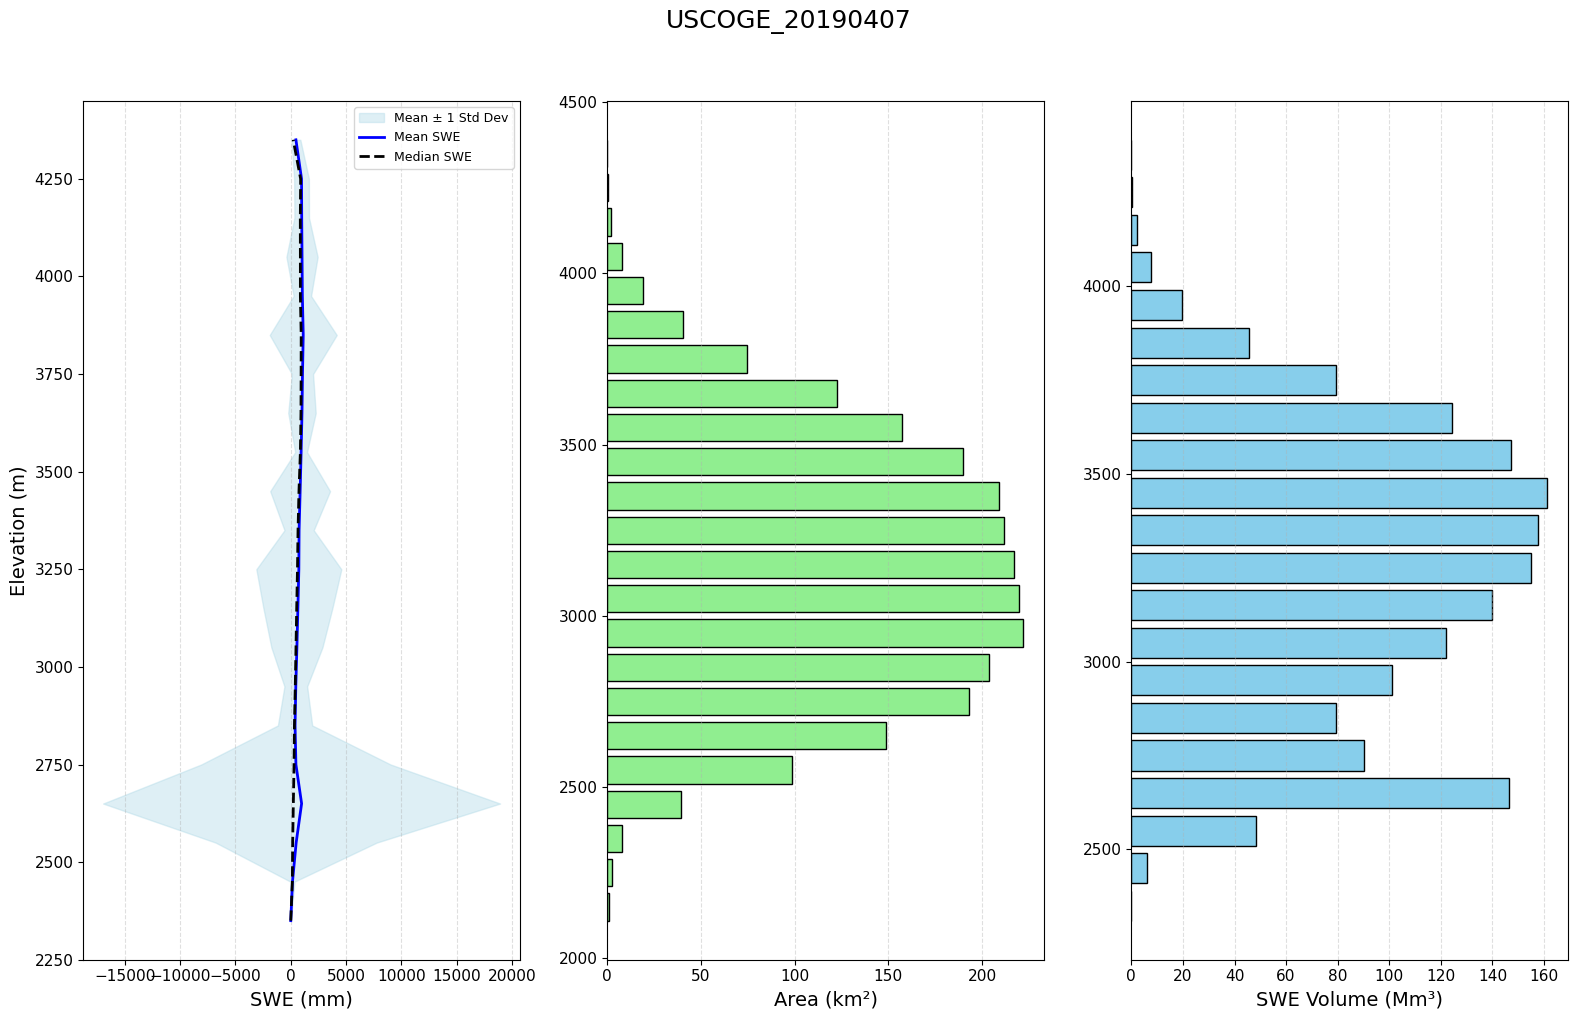

In [26]:
plot_triple(z_centers, mean_swe3, std_swe3, median_swe3,area_km2,swe_volumn3,plot_label3)

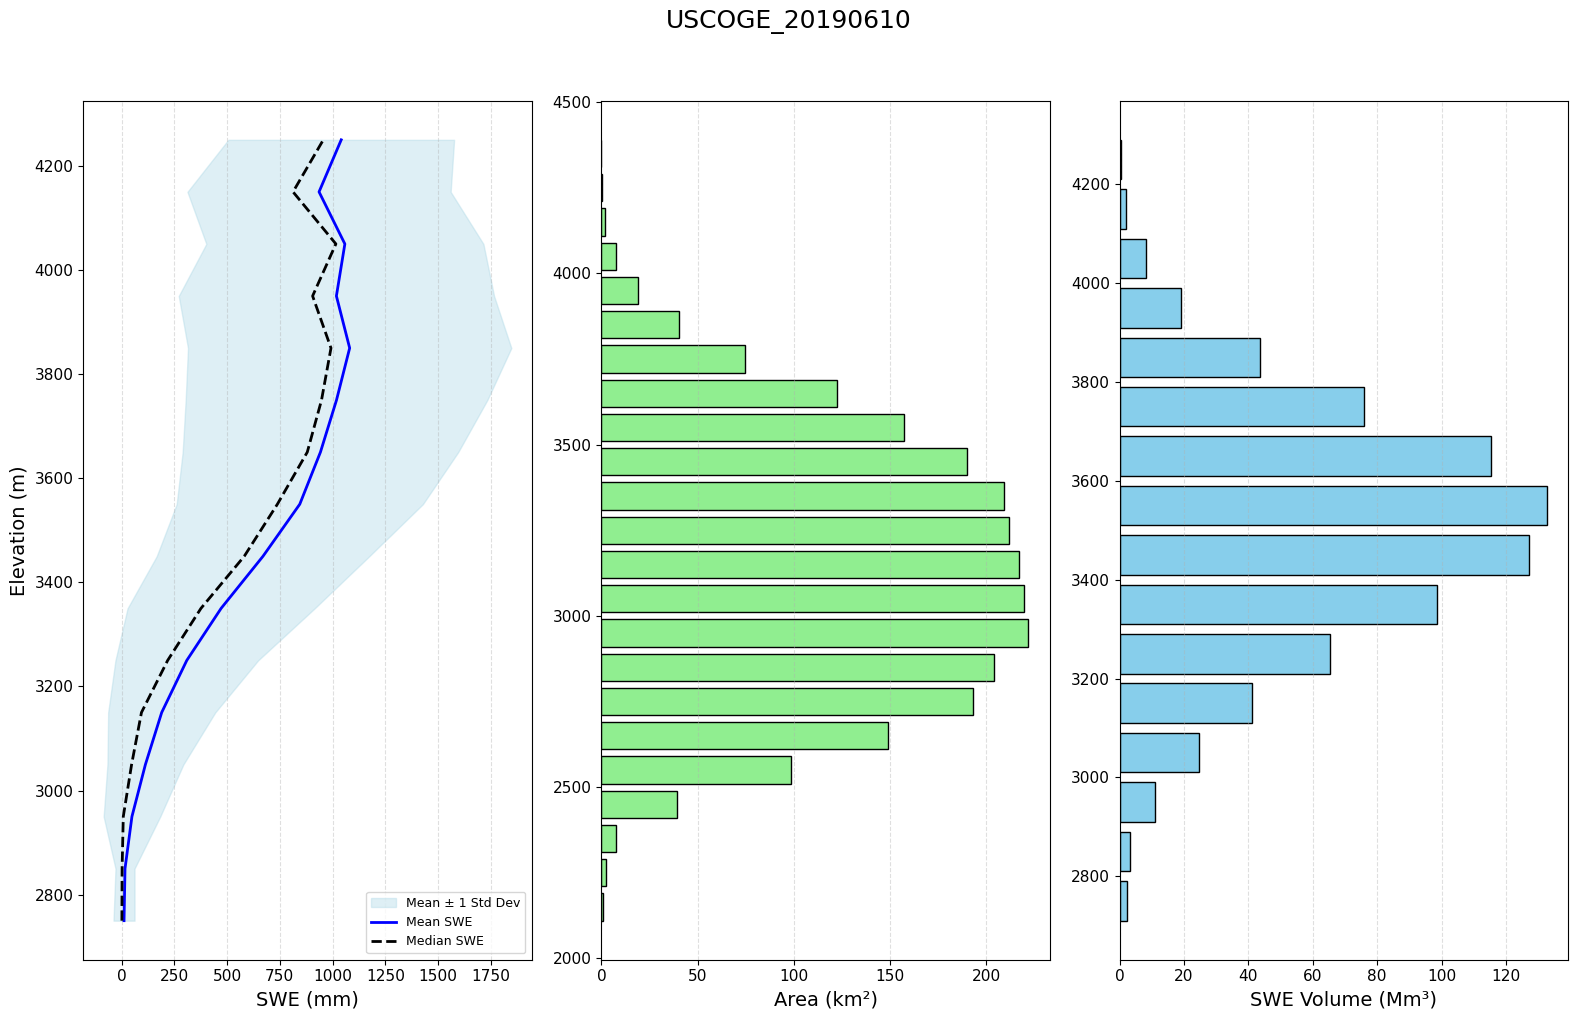

In [27]:
plot_triple(z_centers, mean_swe4, std_swe4, median_swe4,area_km2,swe_volumn4,plot_label4)

### Discussion:

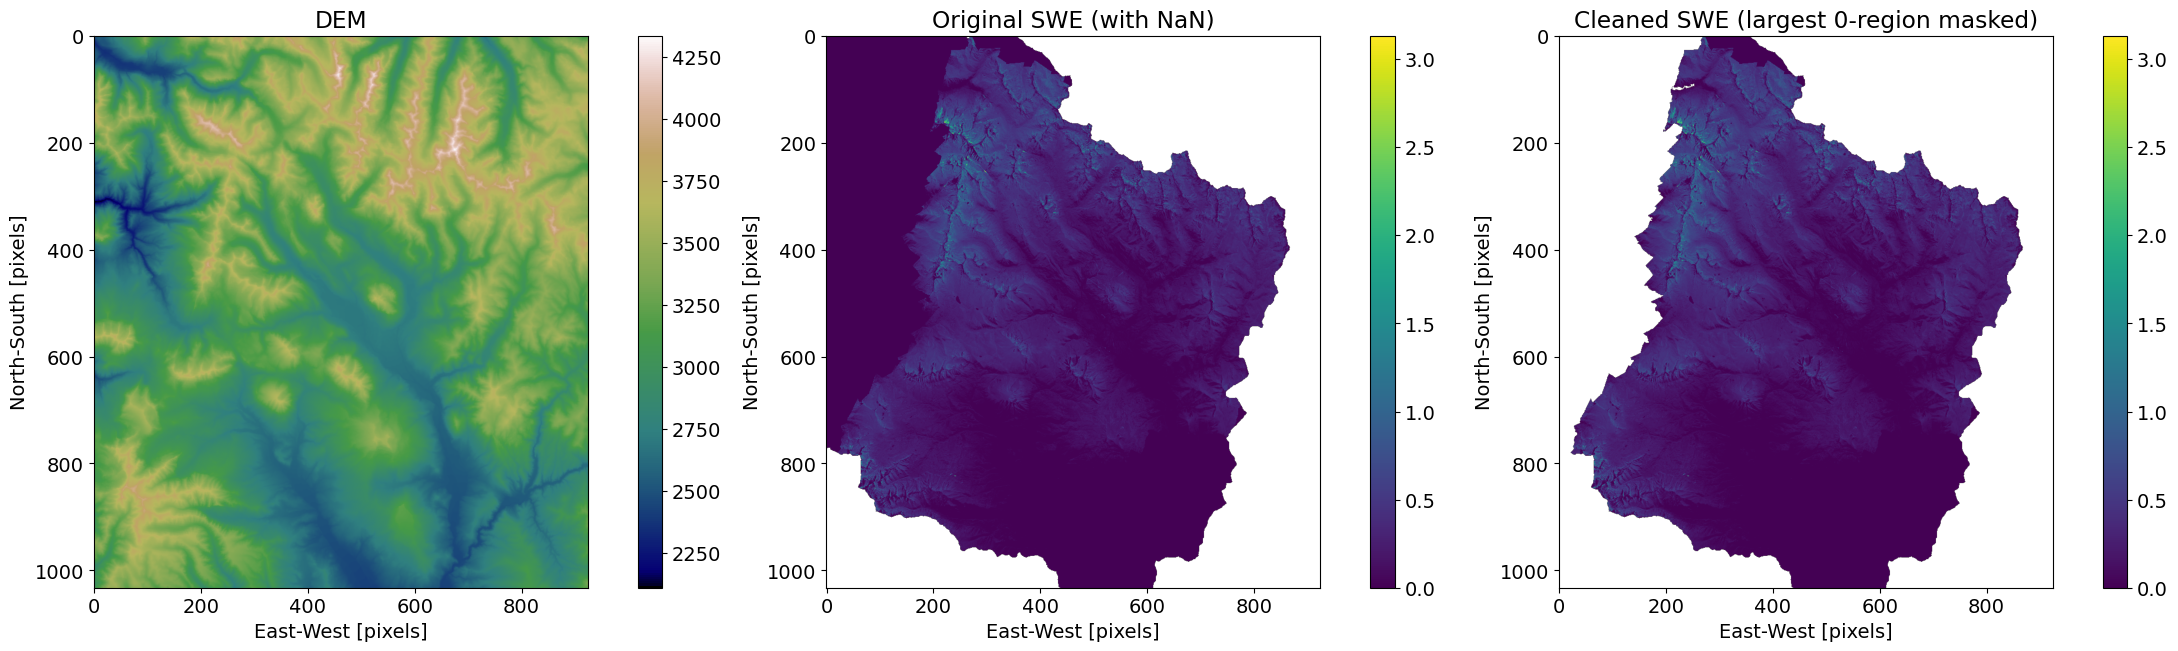

In [46]:
swe_array1_nan = swe_array1.copy()
swe_array1_nan[swe_array1_nan == -9999.0] = np.nan
# Clean SWE by removing largest zero region
swe_clean = swe_array1.copy()
swe_clean[swe_clean == -9999.0] = np.nan

zero_mask = (swe_clean == 0)
labeled, num_features = label(zero_mask)

sizes = [(labeled == i).sum() for i in range(1, num_features+1)]

if len(sizes) > 0:
    largest_region = np.argmax(sizes) + 1
    swe_clean[labeled == largest_region] = np.nan

# Plot 3 maps in one row
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(1, 3, figsize=(22, 7))   # wider for 3 plots

# Plot 1: DEM
ax = axs[0]
im0 = ax.imshow(dem_array, cmap='gist_earth')
ax.set_title("DEM")
ax.set_xlabel("East-West [pixels]")
ax.set_ylabel("North-South [pixels]")

divider0 = make_axes_locatable(ax)
cax0 = divider0.new_horizontal(size='5%', pad=0.5)
fig.add_axes(cax0)
fig.colorbar(im0, cax=cax0)

# Plot 2: Original SWE (NaN filled)
ax = axs[1]
im1 = ax.imshow(swe_array1_nan, cmap='viridis')
ax.set_title("Original SWE (with NaN)")
ax.set_xlabel("East-West [pixels]")
ax.set_ylabel("North-South [pixels]")

divider1 = make_axes_locatable(ax)
cax1 = divider1.new_horizontal(size='5%', pad=0.5)
fig.add_axes(cax1)
fig.colorbar(im1, cax=cax1)

# Plot 3: Cleaned SWE
ax = axs[2]
im2 = ax.imshow(swe_clean, cmap='viridis')
ax.set_title("Cleaned SWE (largest 0-region masked)")
ax.set_xlabel("East-West [pixels]")
ax.set_ylabel("North-South [pixels]")

divider2 = make_axes_locatable(ax)
cax2 = divider2.new_horizontal(size='5%', pad=0.5)
fig.add_axes(cax2)
fig.colorbar(im2, cax=cax2)

plt.tight_layout()
plt.show()


From the three images above, we can see that the DEM data is correct and covers the entire area. However, the SWE data contains an incorrect region in the upper-left portion of the map. According to the DEM, the hill in that location should be continuous, but the original SWE map shows a large area of zero values. This is likely due to measurement error. Therefore, this region needs to be cleaned. In this problem, I masked out the largest connected zero-value region to remove the invalid data.

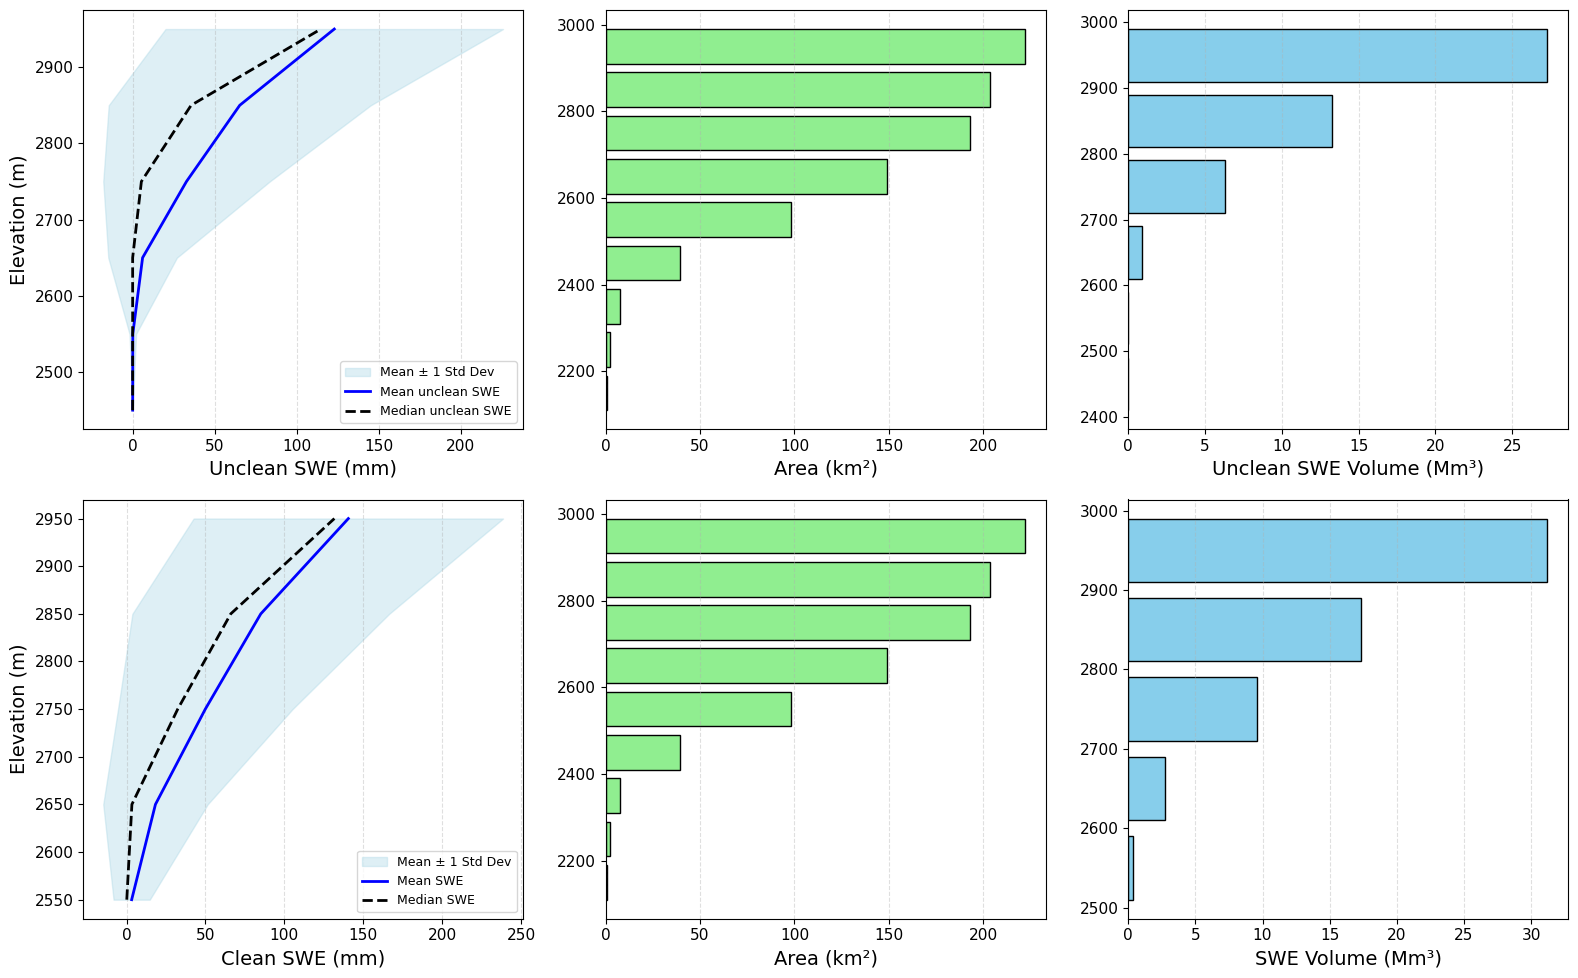

In [ ]:
delta_z = 100

# only focus on 1000–3000 m 
mask = (z_centers >= 100) & (z_centers <= 3000)

z_plot = z_centers[mask]

mean_sweun_plot    = mean_sweun1[mask]
std_sweun_plot     = std_sweun1[mask]
median_sweun_plot  = median_sweun1[mask]

mean_swe_plot      = mean_swe1[mask]
std_swe_plot       = std_swe1[mask]
median_swe_plot    = median_swe1[mask]

area_plot          = area_km2[mask]
swe_volumnun_plot  = swe_volumnun1[mask]
swe_volumn_plot    = swe_volumn1[mask]
# ============================================

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axs = axs.ravel()

# --------- 图 1：unclean mean/median/std ----------
axs[0].fill_betweenx(
    y=z_plot,
    x1=(mean_sweun_plot - std_sweun_plot) * 1000,
    x2=(mean_sweun_plot + std_sweun_plot) * 1000,
    color='lightblue', alpha=0.4,
    label="Mean ± 1 Std Dev"
)

axs[0].plot(mean_sweun_plot * 1000, z_plot,
            color='blue', linewidth=2, label='Mean unclean SWE')
axs[0].plot(median_sweun_plot * 1000, z_plot,
            color='black', linestyle='--', linewidth=2, label='Median unclean SWE')

axs[0].set_xlabel("Unclean SWE (mm)")
axs[0].set_ylabel("Elevation (m)")
axs[0].grid(axis='x', linestyle='--', alpha=0.4)
axs[0].legend(fontsize=9)

# --------- 图 2：unclean area ----------
axs[1].barh(
    y=z_plot,
    width=area_plot,
    height=delta_z * 0.8,
    color='lightgreen', edgecolor='k'
)
axs[1].set_xlabel("Area (km²)")
axs[1].grid(axis='x', linestyle='--', alpha=0.4)

# --------- 图 3：unclean SWE volume ----------
axs[2].barh(
    y=z_plot,
    width=swe_volumnun_plot,
    height=delta_z * 0.8,
    color='skyblue', edgecolor='k'
)
axs[2].set_xlabel("Unclean SWE Volume (Mm³)")
axs[2].grid(axis='x', linestyle='--', alpha=0.4)

# --------- 图 4：clean mean/median ----------
axs[3].fill_betweenx(
    y=z_plot,
    x1=(mean_swe_plot - std_swe_plot) * 1000,
    x2=(mean_swe_plot + std_swe_plot) * 1000,
    color='lightblue', alpha=0.4,
    label="Mean ± 1 Std Dev"
)
axs[3].plot(mean_swe_plot * 1000, z_plot,
            color='blue', linewidth=2, label='Mean SWE')
axs[3].plot(median_swe_plot * 1000, z_plot,
            color='black', linestyle='--', linewidth=2, label='Median SWE')

axs[3].set_xlabel("Clean SWE (mm)")
axs[3].set_ylabel("Elevation (m)")
axs[3].grid(axis='x', linestyle='--', alpha=0.4)
axs[3].legend(fontsize=9)

# --------- 图 5：clean area ----------
axs[4].barh(
    y=z_plot,
    width=area_plot,
    height=delta_z * 0.8,
    color='lightgreen', edgecolor='k'
)
axs[4].set_xlabel("Area (km²)")
axs[4].grid(axis='x', linestyle='--', alpha=0.4)

# --------- 图 6：clean SWE volume ----------
axs[5].barh(
    y=z_plot,
    width=swe_volumn_plot,
    height=delta_z * 0.8,
    color='skyblue', edgecolor='k'
)
axs[5].set_xlabel("SWE Volume (Mm³)")
axs[5].grid(axis='x', linestyle='--', alpha=0.4)

# --------- 全局 tick size ----------
for ax in axs:
    ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()


From the six images above, we can see that cleaning the erroneous data only affects the SWE volume, which is reasonable. Since the erroneous zero-value region does not contain any actual SWE, it does not change the total area with SWE. However, it does influence statistical characteristics such as the mean and median SWE values. 

From this example, I learned that when analyzing geospatial data, we cannot rely solely on numerical statistics. Visualizing the data through maps provides a more direct and intuitive understanding, and can help identify issues that numerical summaries may miss.